Purpose: Summarize the time-structured CAM genes for each genotype and across all genotypes.<br>
Author: Anna Pardo<br>
Date initiated: Jan. 5, 2026

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
physcat = json.load(open("../../phys_figures/physiological_CAM_categories.json"))

In [3]:
# load CAM genes annotation
camgenes = pd.read_csv("../degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")
camgenes.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [4]:
# load time-structured gene information
cinfo = pd.read_csv("./clusters_ngenes_gt_ztgroup_with36-61-43.txt",sep="\t",header="infer")
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0.0,319,53_1,5.0
1,2,53,1.0,656,53_2,21.0
2,3,53,1.0,882,53_3,17.0
3,4,53,0.0,1071,53_4,9.0
4,5,53,0.0,428,53_5,21.0


In [5]:
cinfo["n_CAM_genes"] = cinfo["n_CAM_genes"].astype(int)

In [5]:
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0,319,53_1,5.0
1,2,53,1,656,53_2,21.0
2,3,53,1,882,53_3,17.0
3,4,53,0,1071,53_4,9.0
4,5,53,0,428,53_5,21.0


In [6]:
# set up a column in the 'cam' object stating whether a gene is time-structured or not, 
# and if so, what cluster & ZTpeak is it in? (separate columns)

# to do this: load cluster membership data
# define a function to load & summarize the data for a given genotype
def load_sum_gt(gt):
    if gt in ["all","gt37"]:
        if gt=="all":
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_18-Nov.tsv",sep="\t",header="infer")
        else:
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_17-Nov.tsv",sep="\t",header="infer")
            gt = "37"
    else:
        gtc = pd.read_csv("./Yg"+gt+"_hclust_k6_clusters.txt",sep="\t",header="infer")
        
    gtc["genotype"] = gt
    # set up a CAM column
    camornot = []
    for i in gtc["GeneID"]:
        if i in camids:
            camornot.append("Y")
        else:
            camornot.append("N")
    gtc["CAM_notCAM"] = camornot
    
    # set up a subgenome column
    sg = []
    for i in gtc["GeneID"]:
        if i.startswith("Yucal"):
            sg.append("Ya")
        else:
            sg.append("Yf")
    gtc["subgenome"] = sg
    
    # set up a genotype_cluster column
    gtc["gtc"] = gtc["genotype"]+"_"+gtc["cluster"].astype(str)
    
    return gtc

In [7]:
camids = list(camgenes["GeneID"].unique())

In [8]:
dflist = []
for f in os.listdir("./"):
    if(f.endswith("clusters.txt") and f.startswith("Yg")):
        print(f)
        gt = f.split("_")[0].lstrip("Yg")
        print(gt)
        dflist.append(load_sum_gt(gt))
dflist.append(load_sum_gt("gt37"))

YgG_hclust_k6_clusters.txt
G
YgEudy_hclust_k6_clusters.txt
Eudy
Yg36_hclust_k6_clusters.txt
36
Yg43_hclust_k6_clusters.txt
43
Yg13_hclust_k6_clusters.txt
13
Yg45_hclust_k6_clusters.txt
45
Yg19_hclust_k6_clusters.txt
19
Yg51_hclust_k6_clusters.txt
51
Yg2AB_hclust_k6_clusters.txt
2AB
Yg52_hclust_k6_clusters.txt
52
Yg46_hclust_k6_clusters.txt
46
Yg70_hclust_k6_clusters.txt
70
Yg48_hclust_k6_clusters.txt
48
Yg55_hclust_k6_clusters.txt
55
Yg18_hclust_k6_clusters.txt
18
Yg61_hclust_k6_clusters.txt
61
Yg53_hclust_k6_clusters.txt
53
Yg56_hclust_k6_clusters.txt
56
Yg1AB_hclust_k6_clusters.txt
1AB


In [9]:
allclusters = pd.concat(dflist)
allclusters.head()

,cluster,GeneID,genotype,CAM_notCAM,subgenome,gtc
0,1,Yucal.01G003400.v2.1,G,N,Ya,G_1
1,1,Yucal.01G004800.v2.1,G,N,Ya,G_1
2,2,Yucal.01G004900.v2.1,G,N,Ya,G_2
3,3,Yucal.01G005300.v2.1,G,N,Ya,G_3
4,4,Yucal.01G012100.v2.1,G,N,Ya,G_4


In [10]:
allclusters["genotype"].unique()

array(['G', 'Eudy', '36', '43', '13', '45', '19', '51', '2AB', '52', '46',
       '70', '48', '55', '18', '61', '53', '56', '1AB', '37'],
      dtype=object)

In [11]:
cinfo["genotype"].unique()

array(['53', 'Eudy', '13', '52', '48', 'G', '19', '46', '56', '45', '18',
       '70', '1AB', '55', '51', '2AB', '37', 'all', '36', '61', '43'],
      dtype=object)

In [10]:
# remove 'all' from cinfo
cinfo = cinfo[cinfo["genotype"]!="all"]

In [11]:
tccam = camgenes.merge(allclusters,how="inner").drop("CAM_notCAM",axis=1)

In [31]:
tccam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,cluster,genotype,gtc
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,6,36,36_6
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,2,13,13_2
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,5,45,45_5
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,4,19,19_4
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,6,51,51_6


In [33]:
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0,319,53_1,5.0
1,2,53,1,656,53_2,21.0
2,3,53,1,882,53_3,17.0
3,4,53,0,1071,53_4,9.0
4,5,53,0,428,53_5,21.0


In [12]:
# add in ZTpeak information
tccam = tccam.merge(cinfo[["gtc","ZTpeak"]])

In [36]:
tccam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,cluster,genotype,gtc,ZTpeak
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,6,36,36_6,9.0
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya,6,36,36_6,9.0
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya,6,36,36_6,9.0
3,Yucal.05G213700.v2.1,OG0003608,CAM-light,NAD-dependent malic enzyme,NAD-ME,Ya_NAD-ME_3,Ya,6,36,36_6,9.0
4,Yucal.03G000600.v2.1,OG0001861,CAM-light,phosphoenolpyruvate carboxykinase,PEPCK,Ya_PEPCK_1,Ya,6,36,36_6,9.0


In [49]:
camgene_peaks_by_gt = tccam.groupby(["gene_abbr_unique","subgenome","ZTpeak"]).count()[["genotype"]].reset_index()

In [44]:
tccam_families = tccam.drop(["GeneID","gene_abbr_unique"],axis=1).drop_duplicates()
len(tccam_families.index)

362

In [45]:
len(tccam.index)

490

In [46]:
camfam_peaks_by_gt = tccam_families.groupby(["gene_abbr","subgenome","ZTpeak"]).count()[["genotype"]].reset_index()
camfam_peaks_by_gt.head()

,gene_abbr,subgenome,ZTpeak,genotype
0,BPPC,Ya,5.0,4
1,BPPC,Ya,9.0,11
2,BPPC,Ya,17.0,1
3,BPPC,Yf,5.0,3
4,BPPC,Yf,9.0,9


In [50]:
camgene_peaks_by_gt.head()

,gene_abbr_unique,subgenome,ZTpeak,genotype
0,Ya_BPPC_1,Ya,5.0,4
1,Ya_BPPC_1,Ya,9.0,8
2,Ya_BPPC_1,Ya,17.0,1
3,Ya_BPPC_2,Ya,5.0,4
4,Ya_BPPC_2,Ya,9.0,11


In [83]:
CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']
# from https://gist.github.com/thriveth/8560036

In [86]:
custompal = {
    1.0:'#377eb8',
    5.0:'#ff7f00',
    9.0:'#4daf4a',
    13.0:'#f781bf',
    17.0:'#a65628',
    21.0:'#984ea3'
}

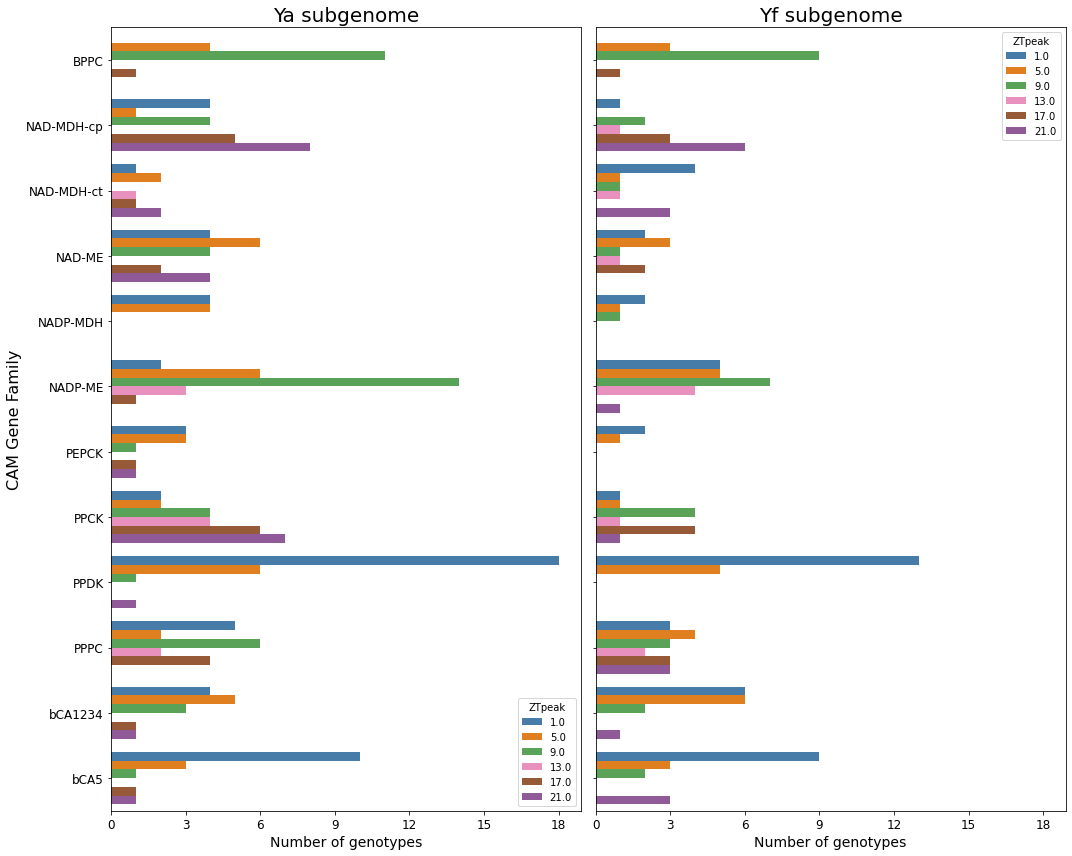

In [90]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(15,12),sharey=True,sharex=True)
sns.barplot(ax=ax[0],data=camfam_peaks_by_gt[camfam_peaks_by_gt["subgenome"]=="Ya"],
            y="gene_abbr",x="genotype",hue="ZTpeak",palette=custompal)

sns.barplot(ax=ax[1],data=camfam_peaks_by_gt[camfam_peaks_by_gt["subgenome"]=="Yf"],
            y="gene_abbr",x="genotype",hue="ZTpeak",palette=custompal)

ax[1].set_ylabel("")
ax[0].set_ylabel("CAM Gene Family",fontsize=16)
ax[0].tick_params(axis="both",labelsize=12)
ax[1].tick_params(axis="both",labelsize=12)

ax[0].set_title("Ya subgenome",fontsize=20)
ax[1].set_title("Yf subgenome",fontsize=20)

ax[0].set_xlabel("Number of genotypes",fontsize=14)
ax[1].set_xlabel("Number of genotypes",fontsize=14)

plt.xticks(ticks=range(0,max(camfam_peaks_by_gt["genotype"])+1,3))
fig.tight_layout()

plt.savefig("./tscam_family_ngenotypes_by_ztpeak_subg_summary.png",dpi=200,bbox_inches="tight")
plt.savefig("./tscam_family_ngenotypes_by_ztpeak_subg_summary.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./tscam_family_ngenotypes_by_ztpeak_subg_summary.svg",dpi=200,bbox_inches="tight")

## New section: plot BPPC profiles

In [13]:
# load TPM
mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_21018/3042139734.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [14]:
mdtpm["genotype"] = mdtpm["genotype"].astype(str)
mdtpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [15]:
bppcs = list(camgenes[camgenes["gene_abbr"]=="BPPC"]["GeneID"].unique())

In [16]:
bppc_tpm = mdtpm[["sample_name","genotype","treat","ZT"]+bppcs]
bppc_tpm.head()

,sample_name,genotype,treat,ZT,Yucal.07G108300.v2.1,Yucal.07G108400.v2.1,Yucal.07G108500.v2.1,YufilH1044442m.g
0,Y1,18,W,1.0,47.645585,14.562792,19.086277,43.257760
1,Y10,2AB,W,3.0,39.612085,25.131958,29.706650,90.847938
2,Y100,2AB,W,23.0,37.101730,17.316687,32.637542,71.972223
3,Y101,2AB,D,1.0,32.852926,17.080246,19.772889,67.734688
4,Y103,2AB,D,1.0,53.977262,18.322768,42.215032,83.157984


In [17]:
ztbppc = bppc_tpm[bppc_tpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]

In [18]:
# rework plottpm similarly
def plottpm_genotype_set(gtlist,ztp,tpm=ztbppc):
    pwide = tpm[tpm["genotype"].isin(gtlist)]
    genecols = [c for c in pwide.columns if c.startswith("Y")]
    csgd = {}
    for c in genecols:
        if c.startswith("Yucal"):
            csgd[c] = "Ya"
        else:
            csgd[c] = "Yf"
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=genecols)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    # add subgenome column
    plong["subgenome"] = plong["GeneID"].map(csgd)
    return plong.sort_values(by=["treat","subgenome"],ascending=False)

In [19]:
# reworked plot_profile() function - to plot profiles by subgenome as well as treatment
def plot_profile(cpdf,axc,a,tf,titletext="Genotypes: ",log=False):
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="subgenome")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="subgenome")
    
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title(titletext,fontsize=tf)

In [20]:
# set up data for plotting
## genotype sets: ZT-peaks at 5, 9, and 17
tcbppc = tccam[tccam["gene_abbr"]=="BPPC"]
len(tcbppc.index)

57

In [21]:
ztd = {}
for i in tcbppc["ZTpeak"].unique():
    df = tcbppc[tcbppc["ZTpeak"]==i]
    ztd[i] = list(df["genotype"].unique())

In [22]:
ztd

{5.0: ['56', '51', '55', '36', '48'],
 9.0: ['37', '70', '1AB', '43', '45', '2AB', '46', '61', 'G', '19', '52'],
 17.0: ['18']}

In [23]:
physcat

{'18': 'C3',
 '48': 'facultative_CAM',
 '43': 'facultative_CAM',
 '70': 'C3',
 '61': 'C3',
 '55': 'C3',
 '1AB': 'possible_fac_CAM',
 '52': 'possible_fac_CAM',
 '16': 'facultative_CAM',
 '56': 'C3',
 '53': 'possible_fac_CAM',
 '51': 'possible_fac_CAM',
 '37': 'possible_fac_CAM',
 'G': 'C3',
 '45': 'C3',
 '19': 'facultative_CAM',
 '13': 'C3',
 'Eudy': 'C3',
 '46': 'possible_fac_CAM',
 '15': 'facultative_CAM',
 '2AB': 'possible_fac_CAM',
 '36': 'C3'}

In [25]:
ztdfs = {}
for k,v in ztd.items():
    ztdfs[k] = plottpm_genotype_set(v,k)

In [26]:
list(ztdfs.values())[0].head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
628,SRR10663894,51,W,21.0,YufilH1044442m.g,126.087022,Yf
640,SRR10848884,48,W,9.0,YufilH1044442m.g,54.150182,Yf
639,SRR10663915,51,W,17.0,YufilH1044442m.g,45.091080,Yf
638,SRR10848719,55,W,17.0,YufilH1044442m.g,35.309660,Yf
637,SRR10663918,51,W,21.0,YufilH1044442m.g,0.905432,Yf


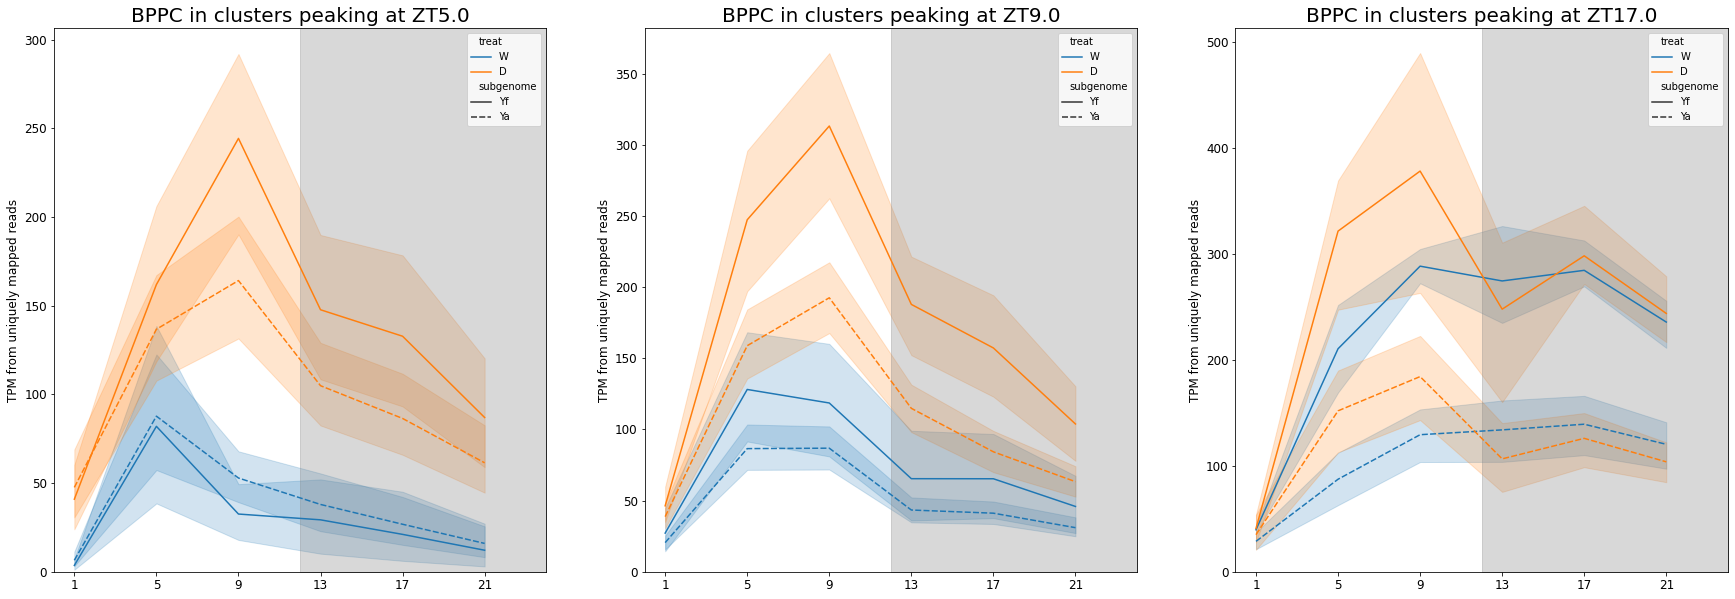

In [27]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(30,10))
for i in range(len(ztdfs.keys())):
    plot_profile(list(ztdfs.values())[i],i,ax,20,titletext="BPPC in clusters peaking at ZT"+str(list(ztdfs.keys())[i]))

In [28]:
bppcdict = camgenes[camgenes["gene_abbr"]=="BPPC"][["GeneID","gene_abbr_unique"]].set_index("GeneID").to_dict()["gene_abbr_unique"]

In [29]:
ztdfs[5.0].head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
628,SRR10663894,51,W,21.0,YufilH1044442m.g,126.087022,Yf
640,SRR10848884,48,W,9.0,YufilH1044442m.g,54.150182,Yf
639,SRR10663915,51,W,17.0,YufilH1044442m.g,45.091080,Yf
638,SRR10848719,55,W,17.0,YufilH1044442m.g,35.309660,Yf
637,SRR10663918,51,W,21.0,YufilH1044442m.g,0.905432,Yf


In [30]:
# try re-plotting this broken out by individual gene ID
# to do so, need to add a gene name column
## also, for good measure, add a CAM physiology column
dflist = []
for k,v in ztdfs.items():
    v["ZT peak"] = k
    v["CAM physiology"] = v["genotype"].map(physcat)
    v["genename"] = v["GeneID"].map(bppcdict)
    dflist.append(v)

In [31]:
allplot = pd.concat(dflist)

In [32]:
allplot.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome,ZT peak,CAM physiology,genename
628,SRR10663894,51,W,21.0,YufilH1044442m.g,126.087022,Yf,5.0,possible_fac_CAM,Yf_BPPC
640,SRR10848884,48,W,9.0,YufilH1044442m.g,54.150182,Yf,5.0,facultative_CAM,Yf_BPPC
639,SRR10663915,51,W,17.0,YufilH1044442m.g,45.091080,Yf,5.0,possible_fac_CAM,Yf_BPPC
638,SRR10848719,55,W,17.0,YufilH1044442m.g,35.309660,Yf,5.0,C3,Yf_BPPC
637,SRR10663918,51,W,21.0,YufilH1044442m.g,0.905432,Yf,5.0,possible_fac_CAM,Yf_BPPC


In [33]:
allplot["ZTpeak_CAM"] = allplot["ZT peak"].astype(int).astype(str)+", "+allplot["CAM physiology"]
allplot.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome,ZT peak,CAM physiology,genename,ZTpeak_CAM
628,SRR10663894,51,W,21.0,YufilH1044442m.g,126.087022,Yf,5.0,possible_fac_CAM,Yf_BPPC,"5, possible_fac_CAM"
640,SRR10848884,48,W,9.0,YufilH1044442m.g,54.150182,Yf,5.0,facultative_CAM,Yf_BPPC,"5, facultative_CAM"
639,SRR10663915,51,W,17.0,YufilH1044442m.g,45.091080,Yf,5.0,possible_fac_CAM,Yf_BPPC,"5, possible_fac_CAM"
638,SRR10848719,55,W,17.0,YufilH1044442m.g,35.309660,Yf,5.0,C3,Yf_BPPC,"5, C3"
637,SRR10663918,51,W,21.0,YufilH1044442m.g,0.905432,Yf,5.0,possible_fac_CAM,Yf_BPPC,"5, possible_fac_CAM"


In [34]:
allplot["ZTpeak_CAM"].unique()

array(['5, possible_fac_CAM', '5, facultative_CAM', '5, C3',
       '9, facultative_CAM', '9, C3', '9, possible_fac_CAM', '17, C3'],
      dtype=object)

In [35]:
# modify plot_profile() to plot lines for each individual gene
def plot_profile_gid(cpdf,axc,a,tf,titletext="Genotypes: ",log=False):
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="genename",palette={"W":"tab:blue","D":"tab:orange"})
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="genename",palette={"W":"tab:blue","D":"tab:orange"})
    
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title(titletext,fontsize=tf)

/tmp/ipykernel_21018/436463943.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf.sort_values(by=["genename"],ascending=False,inplace=True)
/tmp/ipykernel_21018/436463943.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf.sort_values(by=["genename"],ascending=False,inplace=True)
/tmp/ipykernel_21018/436463943.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf.sort_values(by=["genename"],ascending=False,inplace=True)
/tmp

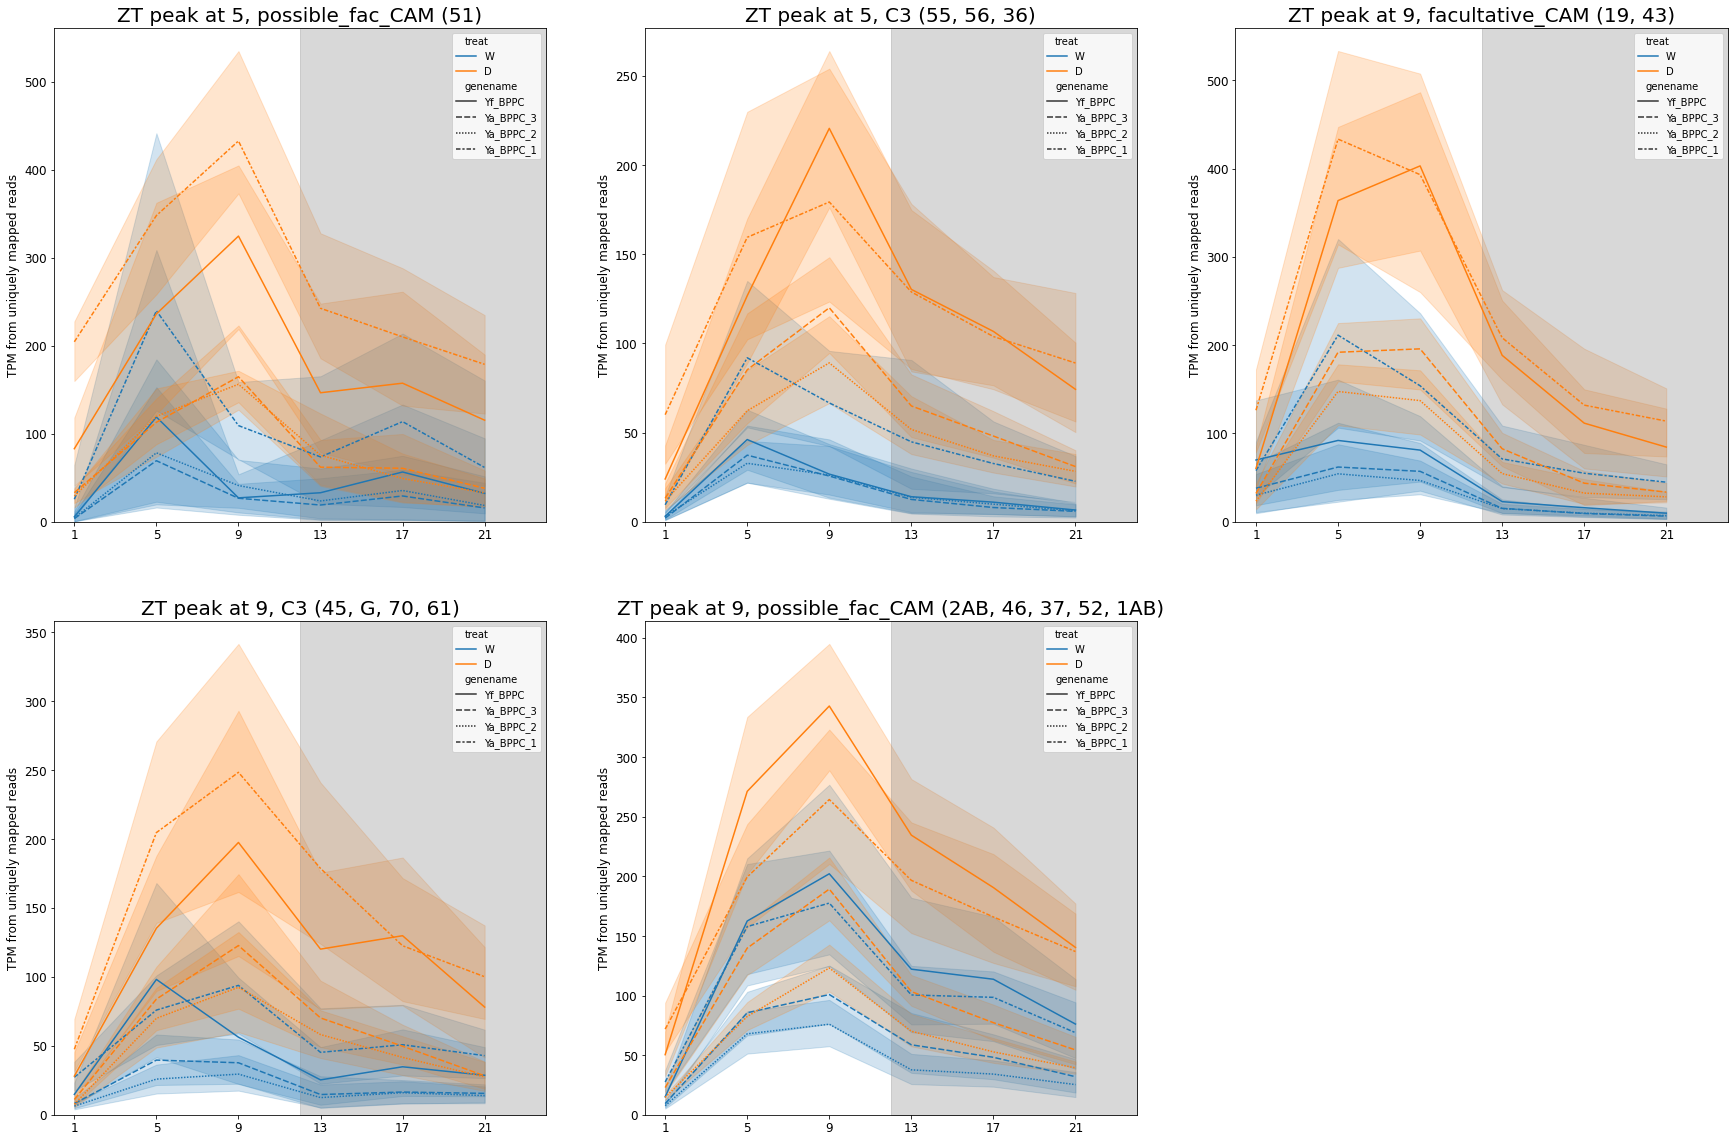

In [36]:
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(30,20))

r = 0
c = 0

for i in allplot["ZTpeak_CAM"].unique():
    if i!="5, facultative_CAM":
        pdf = allplot[allplot["ZTpeak_CAM"]==i]
        pdf.sort_values(by=["genename"],ascending=False,inplace=True)
        #ngt = len(pdf["genotype"].unique())
        gtlist = list(pdf["genotype"].unique())
        gts = str()
        for j in gtlist:
            gts = gts+j+", "
        gts = gts.rstrip(", ")
        plot_profile_gid(pdf,(r,c),ax,20,"ZT peak at "+i+" ("+gts+")")
        if c<2:
            c+=1
        else:
            c=0
            r+=1
            
fig.delaxes(ax[1,2])

plt.savefig("./ztpall_BPPC_exp_by_phys.png",dpi=200,bbox_inches="tight")
plt.savefig("./ztpall_BPPC_exp_by_phys.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./ztpall_BPPC_exp_by_phys.svg",dpi=200,bbox_inches="tight")

/tmp/ipykernel_21018/1380755875.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf.sort_values(by=["genename"],ascending=False,inplace=True)
/tmp/ipykernel_21018/1380755875.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf.sort_values(by=["genename"],ascending=False,inplace=True)
/tmp/ipykernel_21018/1380755875.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pdf.sort_values(by=["genename"],ascending=False,inplace=True)


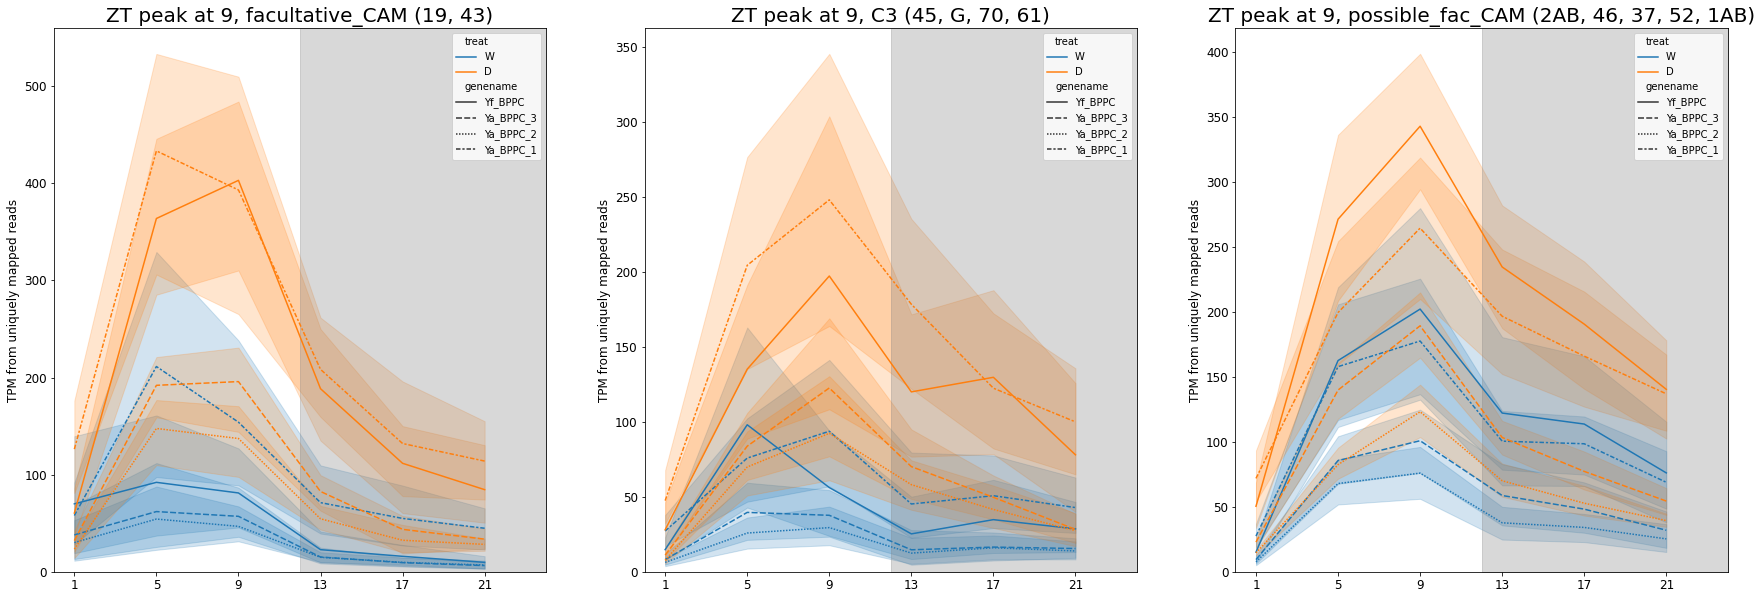

In [37]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(30,10))

c = 0

for i in allplot["ZTpeak_CAM"].unique():
    if i.startswith("9"):
        pdf = allplot[allplot["ZTpeak_CAM"]==i]
        pdf.sort_values(by=["genename"],ascending=False,inplace=True)
        #ngt = len(pdf["genotype"].unique())
        gtlist = list(pdf["genotype"].unique())
        gts = str()
        for j in gtlist:
            gts = gts+j+", "
        gts = gts.rstrip(", ")
        plot_profile_gid(pdf,c,ax,20,"ZT peak at "+i+" ("+gts+")")
        c+=1
            
plt.savefig("./ztp9_BPPC_exp_by_phys.png",dpi=200,bbox_inches="tight")
plt.savefig("./ztp9_BPPC_exp_by_phys.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./ztp9_BPPC_exp_by_phys.svg",dpi=200,bbox_inches="tight")

In [38]:
tccam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,cluster,genotype,gtc,ZTpeak
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,6,36,36_6,9.0
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya,6,36,36_6,9.0
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya,6,36,36_6,9.0
3,Yucal.05G213700.v2.1,OG0003608,CAM-light,NAD-dependent malic enzyme,NAD-ME,Ya_NAD-ME_3,Ya,6,36,36_6,9.0
4,Yucal.03G000600.v2.1,OG0001861,CAM-light,phosphoenolpyruvate carboxykinase,PEPCK,Ya_PEPCK_1,Ya,6,36,36_6,9.0


In [39]:
tcbppc[tcbppc["gene_abbr_unique"]=="Yf_BPPC"].sort_values(by="ZTpeak")

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,cluster,genotype,gtc,ZTpeak
65,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,3,56,56_3,5.0
133,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,2,51,51_2,5.0
336,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,1,36,36_1,5.0
84,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,4,37,37_4,9.0
295,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,2,1AB,1AB_2,9.0
350,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,4,43,43_4,9.0
359,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,2,45,45_2,9.0
369,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,3,2AB,2AB_3,9.0
378,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,6,46,46_6,9.0
393,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,5,61,61_5,9.0


In [40]:
tcbppc.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,cluster,genotype,gtc,ZTpeak
65,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,3,56,56_3,5.0
75,Yucal.07G108300.v2.1,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Ya_BPPC_1,Ya,4,37,37_4,9.0
76,Yucal.07G108400.v2.1,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Ya_BPPC_2,Ya,4,37,37_4,9.0
77,Yucal.07G108500.v2.1,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Ya_BPPC_3,Ya,4,37,37_4,9.0
84,YufilH1044442m.g,OG0008119,CAM-dark,phosphoenolpyruvate carboxylase (bacterial-type),BPPC,Yf_BPPC,Yf,4,37,37_4,9.0


In [41]:
# replot this for ONLY genes appearing in the appropriate clusters...
## to do so, wrangle the data a bit
tcbppc2 = tcbppc[["GeneID","gene_abbr_unique","genotype","ZTpeak"]]

In [42]:
tcbppc2.head()

,GeneID,gene_abbr_unique,genotype,ZTpeak
65,YufilH1044442m.g,Yf_BPPC,56,5.0
75,Yucal.07G108300.v2.1,Ya_BPPC_1,37,9.0
76,Yucal.07G108400.v2.1,Ya_BPPC_2,37,9.0
77,Yucal.07G108500.v2.1,Ya_BPPC_3,37,9.0
84,YufilH1044442m.g,Yf_BPPC,37,9.0


In [43]:
tcbppc2.rename(columns={"gene_abbr_unique":"genename"},inplace=True)

/tmp/ipykernel_21018/1994058961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tcbppc2.rename(columns={"gene_abbr_unique":"genename"},inplace=True)


In [44]:
tcbppc2[(tcbppc2["genename"]=="Yf_BPPC")&(tcbppc2["ZTpeak"]==5.0)]

,GeneID,genename,genotype,ZTpeak
65,YufilH1044442m.g,Yf_BPPC,56,5.0
133,YufilH1044442m.g,Yf_BPPC,51,5.0
336,YufilH1044442m.g,Yf_BPPC,36,5.0


In [45]:
# make another function to appropriately subset allplot by genename & ZT peak (should contain ONLY genotypes in which the 
## genename appears in clusters at that ZTpeak for those genotypes)

def sub_plotdata(gn,ztp,md=tcbppc2,pdf=allplot):
    mdsub = md[(md["genename"]==gn)&(md["ZTpeak"]==ztp)]
    gts = list(mdsub["genotype"].unique())
    datasub = pdf[(pdf["genotype"].isin(gts))&(pdf["genename"]==gn)]
    return datasub

In [46]:
sub_plotdata("Yf_BPPC",5.0)["genotype"].unique()

array(['51', '36', '56'], dtype=object)

In [182]:
# I'm not convinced the above is working...so I'm going to make a function instead to subset & wrangle directly from ztbppc
ztbppc.head()

,sample_name,genotype,treat,ZT,Yucal.07G108300.v2.1,Yucal.07G108400.v2.1,Yucal.07G108500.v2.1,YufilH1044442m.g
0,Y1,18,W,1.0,47.645585,14.562792,19.086277,43.257760
3,Y101,2AB,D,1.0,32.852926,17.080246,19.772889,67.734688
4,Y103,2AB,D,1.0,53.977262,18.322768,42.215032,83.157984
5,Y104,1AB,W,21.0,31.578968,10.623114,10.017172,36.534120
6,Y105,18,W,21.0,124.717355,66.768211,96.461983,211.349550


In [47]:
def sub_bppc_tpm(gid,ztp,md=tcbppc2,tpm=ztbppc):
    mdsub = md[(md["GeneID"]==gid)&(md["ZTpeak"]==ztp)]
    gts = list(mdsub["genotype"].unique())
    
    subtpm = tpm[["sample_name","genotype","treat","ZT",gid]]
    sub2 = subtpm[subtpm["genotype"].isin(gts)]
    sub2["GeneID"] = gid
    sub2 = sub2.rename(columns={gid:"TPM"})
    return sub2

In [48]:
ztp_plot = {}
for i in list(tcbppc2["ZTpeak"].unique()):
    md = tcbppc2[tcbppc2["ZTpeak"]==i]
    dflist = []
    for j in md["GeneID"].unique():
        dflist.append(sub_bppc_tpm(j,i,md))
    df = pd.concat(dflist)
    df["genename"] = df["GeneID"].map(bppcdict)
    df["CAM physiology"] = df["genotype"].map(physcat
                                             )
    ztp_plot[i] = df.sort_values(by=["genename","treat"],ascending=False)

/tmp/ipykernel_21018/1404120740.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub2["GeneID"] = gid
/tmp/ipykernel_21018/1404120740.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub2["GeneID"] = gid
/tmp/ipykernel_21018/1404120740.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [49]:
ztp_plot[5.0]["CAM physiology"].unique()

array(['C3', 'possible_fac_CAM', 'facultative_CAM'], dtype=object)

In [50]:
x = ztp_plot[5.0]
x = x[x["CAM physiology"]=="facultative_CAM"]
x["ZT"].unique()

array([ 9.,  5., 21.,  1., 17., 13.])

In [51]:
x = ztp_plot[5.0]
x = x[x["CAM physiology"]=="possible_fac_CAM"]
x["ZT"].unique()

array([ 5., 13.,  9., 17., 21.,  1.])

In [53]:
ztp_plot[9.0]["CAM physiology"].unique()

array(['possible_fac_CAM', 'facultative_CAM', 'C3'], dtype=object)

In [205]:
ztp_plot[17.0]["CAM physiology"].unique()

array(['C3'], dtype=object)

In [54]:
zt5 = ztp_plot[5.0]
zt9 = ztp_plot[9.0]
zt17 = ztp_plot[17.0]

In [57]:
zt9[zt9["CAM physiology"]=="possible_fac_CAM"]["genotype"].unique()

array(['1AB', '2AB', '37', '46', '52'], dtype=object)

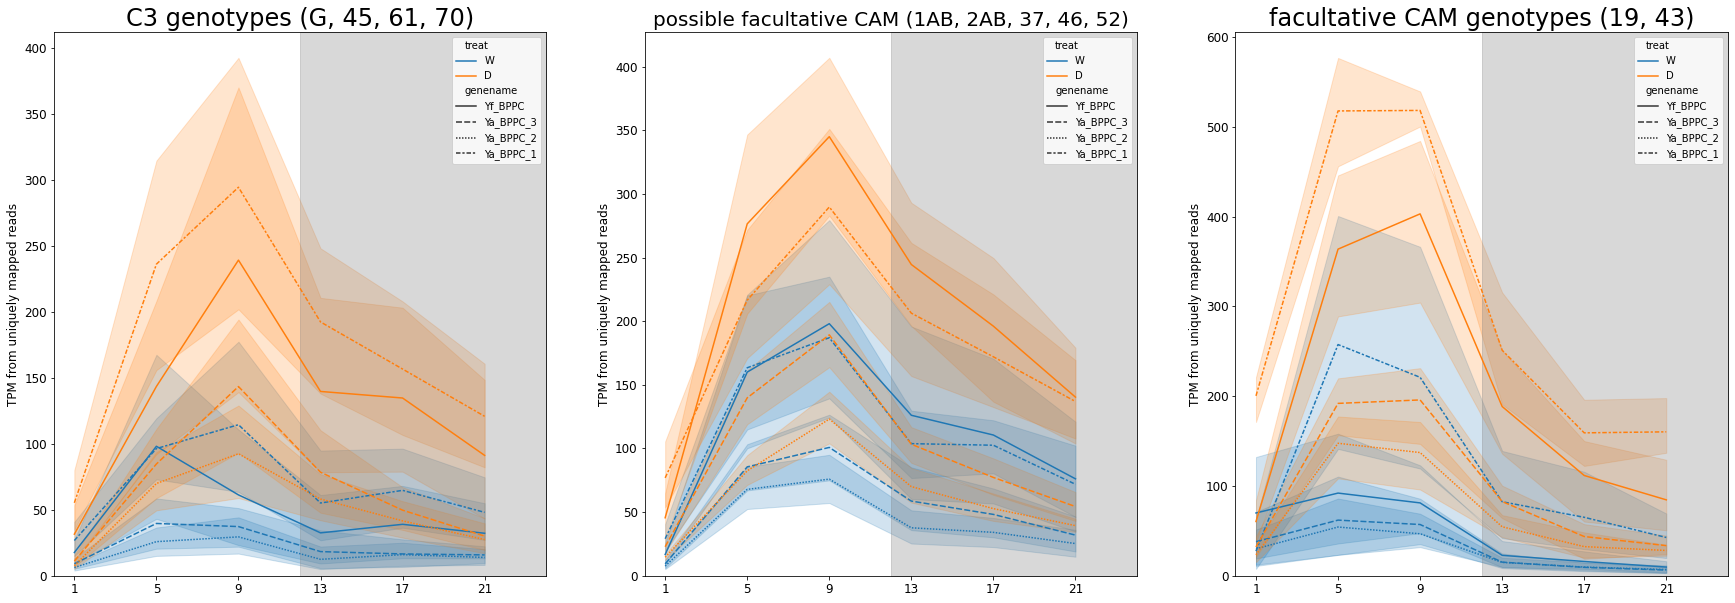

In [58]:
# finally, complete the replot of those peaking at ZT9
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(30,10))

plot_profile_gid(zt9[zt9["CAM physiology"]=="C3"],0,ax,24,"C3 genotypes (G, 45, 61, 70)")
plot_profile_gid(zt9[zt9["CAM physiology"]=="possible_fac_CAM"],1,ax,20,"possible facultative CAM (1AB, 2AB, 37, 46, 52)")
plot_profile_gid(zt9[zt9["CAM physiology"]=="facultative_CAM"],2,ax,24,"facultative CAM genotypes (19, 43)")

plt.savefig("./ztp9_BPPC_exp_by_phys.png",dpi=200,bbox_inches="tight")
plt.savefig("./ztp9_BPPC_exp_by_phys.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./ztp9_BPPC_exp_by_phys.svg",dpi=200,bbox_inches="tight")

In [61]:
zt5[zt5["CAM physiology"]=="C3"]["genotype"].unique()

array(['56', '36', '55'], dtype=object)

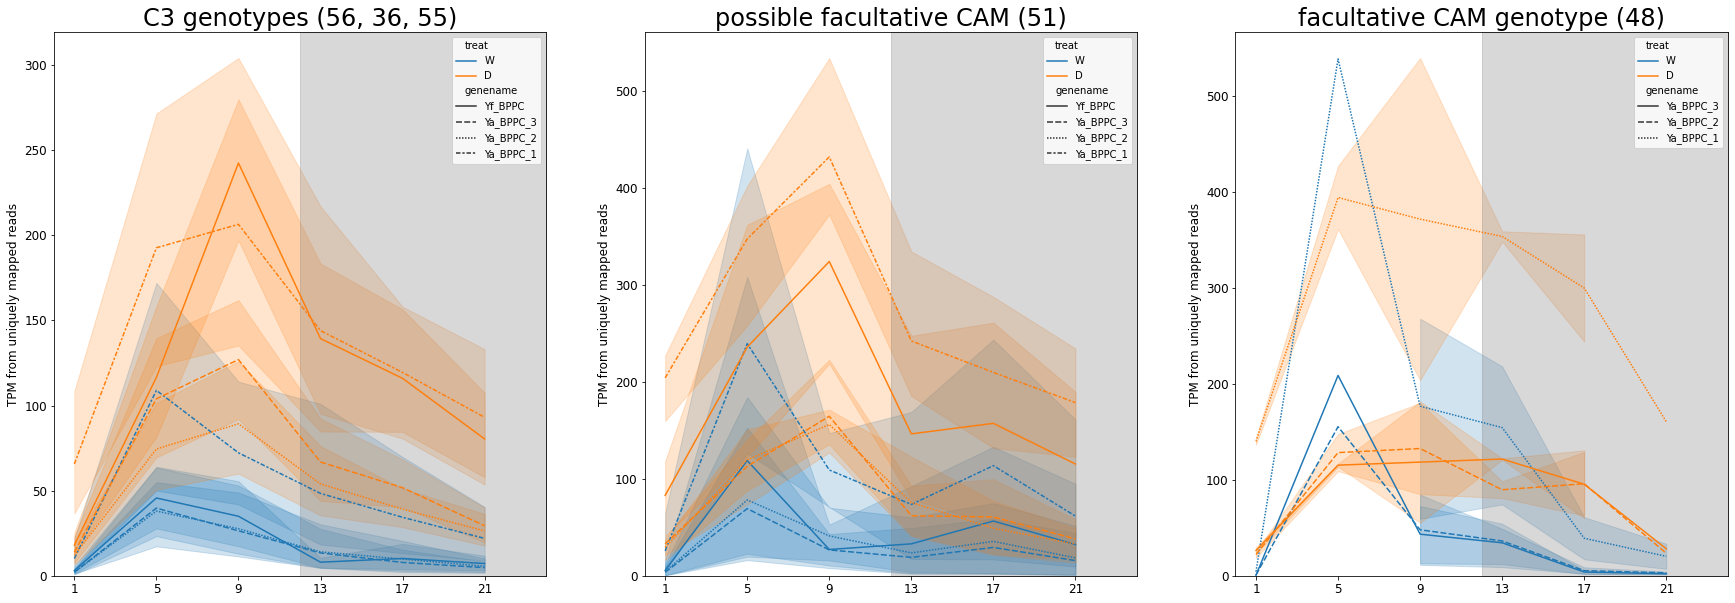

In [64]:
# plot those peaking at ZT5
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(30,10))

plot_profile_gid(zt5[zt5["CAM physiology"]=="C3"],0,ax,24,"C3 genotypes (56, 36, 55)")
plot_profile_gid(zt5[zt5["CAM physiology"]=="possible_fac_CAM"],1,ax,24,"possible facultative CAM (51)")
plot_profile_gid(zt5[zt5["CAM physiology"]=="facultative_CAM"],2,ax,24,"facultative CAM genotype (48)")

plt.savefig("./ztp5_BPPC_exp_by_phys.png",dpi=200,bbox_inches="tight")
plt.savefig("./ztp5_BPPC_exp_by_phys.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./ztp5_BPPC_exp_by_phys.svg",dpi=200,bbox_inches="tight")